In [243]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

In [244]:
OPTIONS = json.loads(open('../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'variable': 'wz', 'test': 1, 'limits': [15, 999]}

In [245]:
TARGET_VAR = OPTIONS.get('variable')
TEST_VAR   = OPTIONS.get('test')

TARGET_TIME = tuple(OPTIONS.get('limits'))
VIEW_LIMITS = (0.2, 0.6)

# DADOS

In [246]:
df = pd.read_csv(f'files/test_{TEST_VAR}_{TARGET_VAR}.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,pitch,ay,az,q1,yaw,wy,time,roll,wz,q3,wx,q0,q2,ax,e
0,861,13643,1000584,0,98,1927,0.000000,2183,-26916,0,-7270,0,0,-38371,0.0
1,860,12747,1003541,0,99,74902,0.010000,2183,8482,0,-31346,0,0,-36711,0.0
2,860,11623,994565,0,100,-41463,0.020000,2183,-11740,0,-7375,0,0,-38477,0.0
3,859,13207,994349,0,100,-3967,0.030000,2183,16996,0,4364,0,0,-37994,0.0
4,860,15791,998421,0,99,-13082,0.040000,2183,-27664,0,19294,0,0,-36898,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13982,77,12186,995215,0,1069,-16302,151.541000,-2912,-68631,0,9921,0,0,49244,0.0
13983,78,12073,999522,0,1075,-27489,151.550995,-2914,-30352,0,-17027,0,0,51033,0.0
13984,80,12427,995420,0,1081,-9455,151.561005,-2915,-53393,0,617,0,0,47824,0.0
13985,82,9165,999482,0,1087,-24669,151.570999,-2915,-42491,0,-28122,0,0,43473,0.0


- Deixando as variaveis no mesmo padrão que a kongsberg

In [247]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,pitch,ay,az,q1,yaw,wy,time,roll,wz,q3,wx,q0,q2,ax,e
0,-2183,1000584,13643,0,98,26916,0.00,861,1927,0,-7270,0,0,-38371,0.0
1,-2183,1003541,12747,0,99,-8482,0.01,860,74902,0,-31346,0,0,-36711,0.0
2,-2183,994565,11623,0,100,11740,0.02,860,-41463,0,-7375,0,0,-38477,0.0
3,-2183,994349,13207,0,100,-16996,0.03,859,-3967,0,4364,0,0,-37994,0.0
4,-2183,998421,15791,0,99,27664,0.04,860,-13082,0,19294,0,0,-36898,0.0


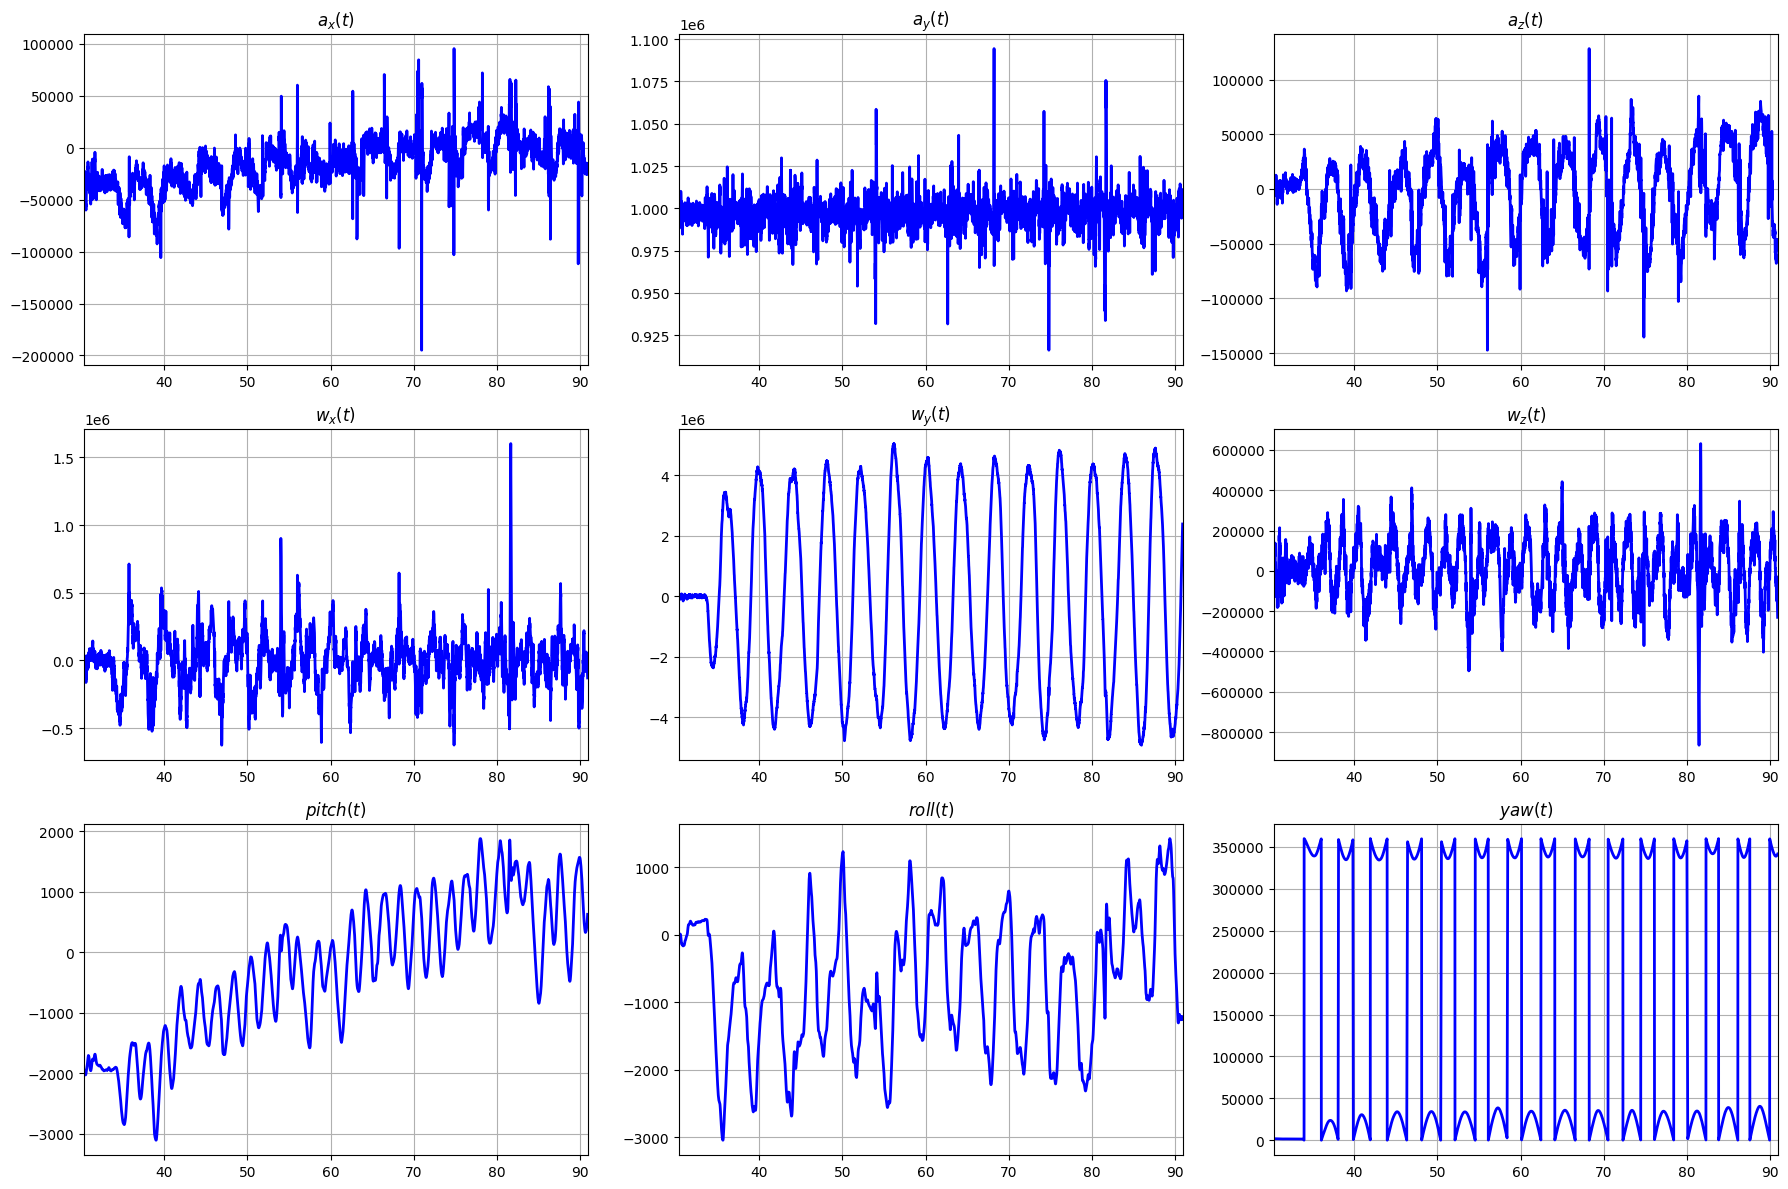

In [248]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals, color='blue', linewidth=2)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, VIEW_LIMITS)

# FILTRANDO POR VARIAVEL

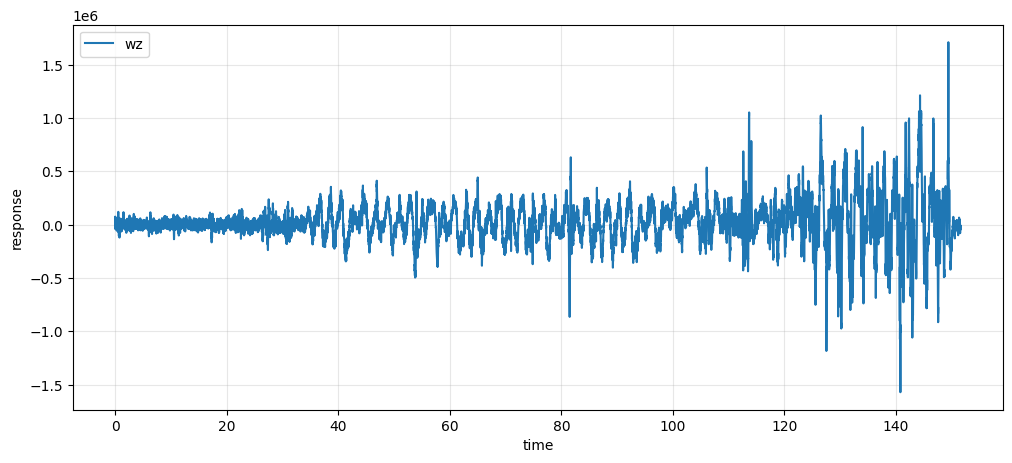

In [249]:
plt.figure(figsize=(12, 5))
plt.plot(df.time, df[TARGET_VAR], label=TARGET_VAR)
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.show()

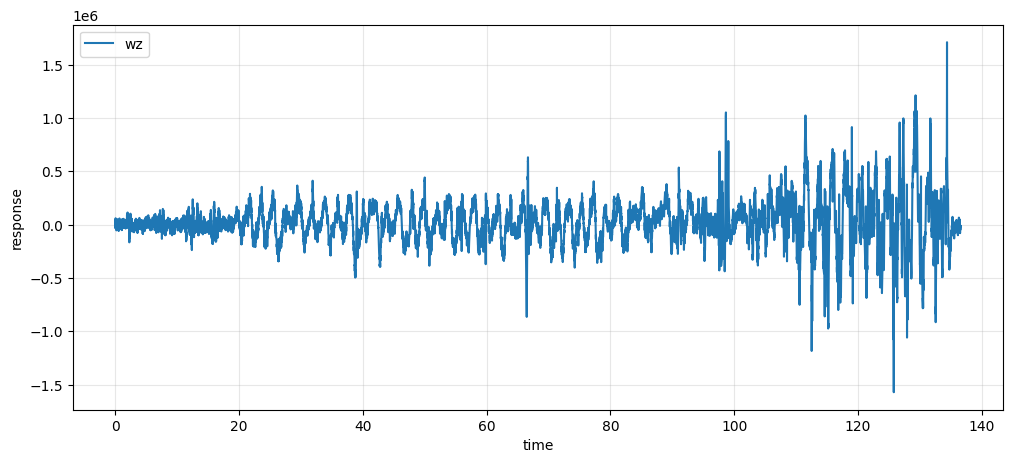

In [250]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

plt.figure(figsize=(12, 5))
plt.plot(df.time, df[TARGET_VAR], label=TARGET_VAR)
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.show()

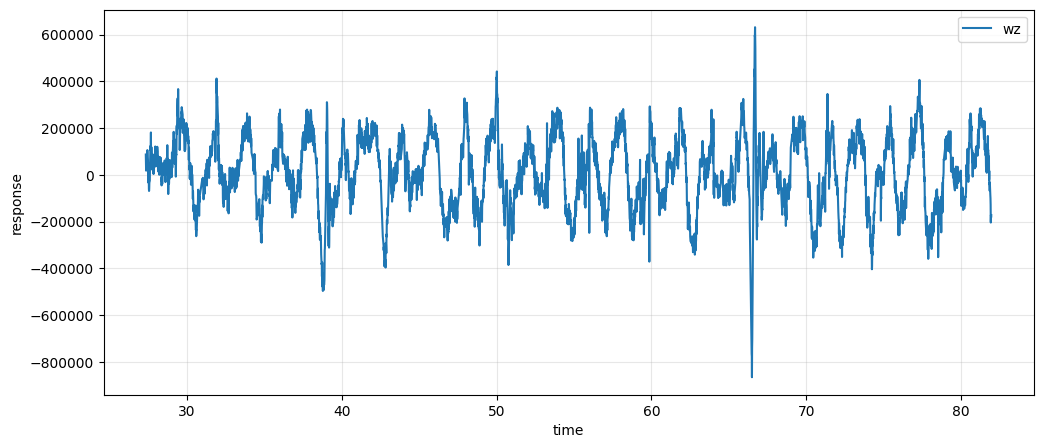

In [251]:
VIEW_TIME = (df.time.values[-1]*VIEW_LIMITS[0], df.time.values[-1]*VIEW_LIMITS[1])
target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

plt.figure(figsize=(12, 5))
plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.show()

In [252]:
df = df.rename(columns={col: 'measure_' + col for col in df.columns if col != 'time'})
df

,measure_pitch,measure_ay,measure_az,measure_q1,measure_yaw,measure_wy,time,measure_roll,measure_wz,measure_q3,measure_wx,measure_q0,measure_q2,measure_ax,measure_e
1492,-2041,995881,10237,0,414,-42019,0.000000,542,16331,0,44195,0,0,-34458,0.0
1493,-2041,998837,15545,0,412,-27233,0.010000,543,-24311,0,17916,0,0,-41115,0.0
1494,-2042,996077,12297,0,411,-20237,0.020000,544,13074,0,-56503,0,0,-36813,0.0
1495,-2043,996806,8643,0,410,-39449,0.030001,544,-33316,0,22885,0,0,-35112,0.0
1496,-2043,996630,8171,0,409,16468,0.040001,544,30717,0,8082,0,0,-35739,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13982,2912,995215,12186,0,1069,68631,136.541000,77,-16302,0,9921,0,0,49244,0.0
13983,2914,999522,12073,0,1075,30352,136.550995,78,-27489,0,-17027,0,0,51033,0.0
13984,2915,995420,12427,0,1081,53393,136.561005,80,-9455,0,617,0,0,47824,0.0
13985,2915,999482,9165,0,1087,42491,136.570999,82,-24669,0,-28122,0,0,43473,0.0


In [253]:
df.to_csv('DataBase.csv', index=None)